In [8]:
#lab 6 -morphological operations
#aim-to study
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
from ipywidgets import interact,IntSlider,Dropdown,Button

Button(description='Generate New Image', style=ButtonStyle())

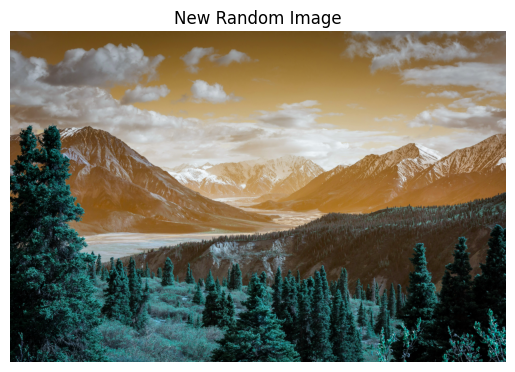

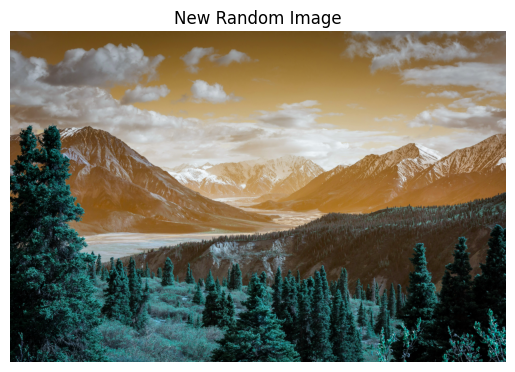

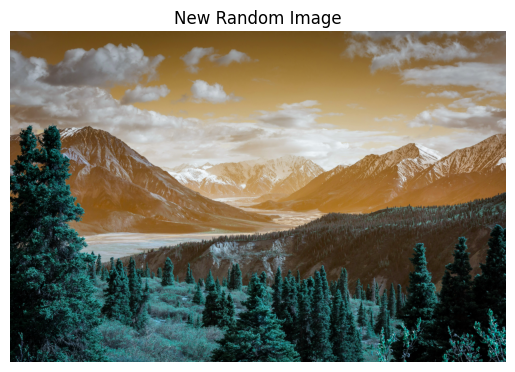

In [14]:
def get_random_image():
  url="https://images.unsplash.com/photo-1464822759023-fed622ff2c3b?ixid=M3w4MjcwNjd8MHwxfHNlYXJjaHwxfHxtb3VudGFpbnN8ZW58MHx8fHwxNzczNzIxMzI2fDA&ixlib=rb-4.1.0&fit=max&q=80"

  response= requests.get(url)

  image_data = BytesIO (response.content)

  pil_image = Image.open(image_data)

 # Convert PIL image to OpenCV format (numpy array, BGR)

  return cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)

def new_image():

  global image, gray, binary

  image = get_random_image()

  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

  binary = cv2.threshold (gray, 120, 255, cv2. THRESH_BINARY)

  plt.imshow(image)

  plt.title("New Random Image")
  plt.axis("off")

button = Button(description="Generate New Image")
button.on_click(lambda x: new_image())

display(button)

Binary image shape: (3840, 5760)


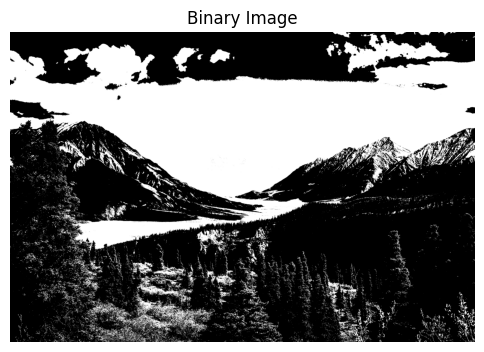

In [15]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

print("Binary image shape:", binary.shape)

plt.figure(figsize=(6,6))
plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis('off')
plt.show()

In [16]:
def get_kernel(shape, size):

    if shape == "Square":
        kernel = np.ones((size, size), np.uint8)

    elif shape == "Cross":
        kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (size, size))

    elif shape == "Ellipse":
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (size, size))

    return kernel

In [17]:
def morphology(image, operation, kernel_size, kernel_shape):

    kernel = get_kernel(kernel_shape, kernel_size)

    if operation == "Erosion":
        result = cv2.erode(image, kernel)

    elif operation == "Dilation":
        result = cv2.dilate(image, kernel)

    elif operation == "Opening":
        result = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

    elif operation == "Closing":
        result = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

    elif operation == "Gradient":
        result = cv2.morphologyEx(image, cv2.MORPH_GRADIENT, kernel)

    elif operation == "Top Hat":
        result = cv2.morphologyEx(image, cv2.MORPH_TOPHAT, kernel)

    elif operation == "Black Hat":
        result = cv2.morphologyEx(image, cv2.MORPH_BLACKHAT, kernel)

    else:
        print("Invalid operation")
        return None

    # Show result
    plt.figure(figsize=(6,6))
    plt.imshow(result, cmap='gray')
    plt.title(f"{operation} | Kernel: {kernel_shape} | Shape: {result.shape}")
    plt.axis("off")
    plt.show()

    return result

In [18]:
def morphology(operation, kernel_size, kernel_shape):

    kernel = get_kernel(kernel_shape, kernel_size)

    if operation == "Erosion":
        result = cv2.erode(binary, kernel)

    elif operation == "Dilation":
        result = cv2.dilate(binary, kernel)

    elif operation == "Opening":
        result = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    elif operation == "Closing":
        result = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    elif operation == "Gradient":
        result = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)
    elif operation == "Top Hat":
        result = cv2.morphologyEx(binary, cv2.MORPH_TOPHAT, kernel)

    elif operation == "Black Hat":
        result = cv2.morphologyEx(binary, cv2.MORPH_BLACKHAT, kernel)

    plt.figure(figsize=(6,6))
    plt.imshow(result, cmap='gray')
    plt.title(operation + " | Kernel: " + kernel_shape)
    plt.axis("off")


interact(
    morphology,
    operation=Dropdown(options=[
        "Erosion",
        "Dilation",
        "Opening",
        "Closing",
        "Gradient",
        "Top Hat",
        "Black Hat"
    ]),
    kernel_size=IntSlider(min=1, max=15, step=2, value=3),
    kernel_shape=Dropdown(options=["Square", "Cross", "Ellipse"])
)

interactive(children=(Dropdown(description='operation', options=('Erosion', 'Dilation', 'Opening', 'Closing', …

<function __main__.morphology(operation, kernel_size, kernel_shape)>